# <CENTER> **PROJECT: Criteo uplift**
<CENTER> ---------------------------------------------------------

---

#### **Постановка задачи:**

В данной работе необходимо подобрать оптимальный алгоритм для оценки аплифт-эффекта от рекламных предложений. Наш клиент — французское рекламное агентство *criteo*. Оно предоставило нам данные о показах рекламы и отклике пользователей на рекламные предложения. Нужно подобрать модель для показа рекламных предложений пользователям.

---


#### **Основные цели:**

* Сформировать набор данных на основе предоставленных источников информации;

* Спроектировать новые признаки с помощью *Feature Engineering* и выявить наиболее значимые при построении модели;

* Исследовать предоставленные данные и выявить закономерности;

* Обучить модель байесовской линейной регрессии с выбранными признаками и получить значение метрики на валидации.

---


#### **Этапы работы над проектом:**

Проект будет состоять из пяти частей:

`1.` *Базовый анализ и знакомство с данными*;

`2.` *Предобработка и очистка данных*;

`3.` *Разведывательный анализ данных (EDA)*;

`4.` *Machine Learning*;

`5.` *Вывод*.

---

**Импортируем библиотеки:**

In [28]:
# Импортируем необходимые библиотека
import pandas as pd
import numpy as np
import os

# Для построения визуализации
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as py
import plotly.io as pio
import arviz as az

# Для построения модели
from sklearn import linear_model
from sklearn.cluster import KMeans
from prophet import Prophet
from sklearn import metrics
import pymc as pm
from sklearn import model_selection
from sklearn import ensemble
from sklift import models
from sklift.metrics import qini_auc_score

# Для проведения статистических тестов
from scipy import stats

**Загружаем данные:**

In [2]:
# Загружаем папку с данными
criteo_uplift_data = pd.read_csv('data/criteo-uplift-v2.1.csv')

# Создаём копию
criteo_uplift_df = criteo_uplift_data.copy()

=============================================================================================================================================

## <center> **`1.` Базовый анализ и знакомство с данными**

На данном этапе изучим информацию предоставленных данных.

#### $1.1$

##### **Выведем информацию по таблицам.**

Создаём функцию:

In [3]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print(f'\nДанные таблицы "{data_name}" имеют следующую размерность:\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем первые пять строк 
    display(data)
    print('-' * length2)

Выводим результат:

In [4]:
# Выводим информацию по полученной таблице при помощи функции 'check_data_inf'
check_data_inf(
    data = criteo_uplift_df,
    data_name = 'criteo_uplift_df',
    length1 = 40,
    length2 = 123
)


Данные таблицы "criteo_uplift_df" имеют следующую размерность:

Количество строк: 13979592;
Количество признаков (столбцов): 16.
----------------------------------------


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13979587,26.297764,10.059654,9.006250,4.679882,10.280525,4.115453,-3.282109,4.833815,3.839578,13.190056,5.300375,-0.168679,1,0,0,0
13979588,12.642207,10.679513,8.214383,-1.700105,10.280525,3.013064,-13.955150,6.269026,3.971858,13.190056,5.300375,-0.168679,1,0,0,1
13979589,12.976557,10.059654,8.381868,0.842442,11.029584,4.115453,-8.281971,4.833815,3.779212,23.570168,6.169187,-0.168679,1,0,1,0
13979590,24.805064,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0


---------------------------------------------------------------------------------------------------------------------------


#### **Основные характеристики:**

Here is a detailed description of the fields (they are comma-separated in the file):

* `f0, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11` - feature values (dense, float);

* `treatment` - treatment group ($1$ = treated, $0$ = control);

* `visit` - whether a visit occured for this user (binary, label);

* `exposure` - treatment effect, whether the user has been effectively exposed (binary).

**target:**

* `conversion` - whether a conversion occured for this user (binary, label).

---

#### $1.2$

Выведем информацию по признакам:

In [5]:
# Вывод таблицы 'criteo_uplift_df'
print('\nИнформация датасета "criteo_uplift_df":\n')
display(criteo_uplift_df.info())
print('-' * 55)


Информация датасета "criteo_uplift_df":

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979592 entries, 0 to 13979591
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   f0          float64
 1   f1          float64
 2   f2          float64
 3   f3          float64
 4   f4          float64
 5   f5          float64
 6   f6          float64
 7   f7          float64
 8   f8          float64
 9   f9          float64
 10  f10         float64
 11  f11         float64
 12  treatment   int64  
 13  conversion  int64  
 14  visit       int64  
 15  exposure    int64  
dtypes: float64(12), int64(4)
memory usage: 1.7 GB


None

-------------------------------------------------------


#### $1.3$

##### **Подсчитаем количество типов данных по признакам.**

Создаём функцию для подсчёта:

In [6]:
# Создаём функцию для рассчёта количества типов по признакам
def check_features_dtypes(data, data_name = None, length1 = None, length2 = None):
    
    # Подсчет количества признаков типа 'object', 'int64' и 'float64'      
    object_columns_count = data.select_dtypes(include = ['object']).shape[1]
    int64_columns_count = data.select_dtypes(include = ['int64']).shape[1]
    float64_columns_count = data.select_dtypes(include = ['float64']).shape[1]
    bool_columns_count = data.select_dtypes(include = ['bool']).shape[1]


    # Вывод результата
    print(f'\nВ таблице "{data_name}" представлены признаки следующих типов:')
    print('-' * length1)
    print()

    print(f"Количество признаков типа 'object': {object_columns_count}")
    print(f"Количество признаков типа 'int64': {int64_columns_count}")
    print(f"Количество признаков типа 'float64': {float64_columns_count}")
    print(f"Количество признаков типа 'bool': {bool_columns_count}")
    print('-' * length2)

Выводим результат:

In [7]:
# Выводим данные таблицы 'criteo_uplift_df'
check_features_dtypes(
    data = criteo_uplift_df,
    data_name =  'criteo_uplift_df',
    length1 = 70,
    length2 = 45
)


В таблице "criteo_uplift_df" представлены признаки следующих типов:
----------------------------------------------------------------------

Количество признаков типа 'object': 0
Количество признаков типа 'int64': 4
Количество признаков типа 'float64': 12
Количество признаков типа 'bool': 0
---------------------------------------------


#### $1.4$

Выведем описательные характеристики по признакам:

In [8]:
# Вывод таблицы
print('\nОписательные характеристики датасета "criteo_uplift_df":')
print('-' * 55)
display(criteo_uplift_df.describe())
print('-' * 123)


Описательные характеристики датасета "criteo_uplift_df":
-------------------------------------------------------


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
count,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07
mean,1.962030e+01,1.006998e+01,8.446582e+00,4.178923e+00,1.033884e+01,4.028513e+00,-4.155356e+00,5.101765e+00,3.933581e+00,1.602764e+01,5.333396e+00,-1.709672e-01,8.500001e-01,2.916680e-03,4.699200e-02,3.063122e-02
std,5.377464e+00,1.047557e-01,2.993161e-01,1.336645e+00,3.433081e-01,4.310974e-01,4.577914e+00,1.205248e+00,5.665958e-02,7.018975e+00,1.682288e-01,2.283277e-02,3.570713e-01,5.392748e-02,2.116217e-01,1.723164e-01
min,1.261636e+01,1.005965e+01,8.214383e+00,-8.398387e+00,1.028053e+01,-9.011892e+00,-3.142978e+01,4.833815e+00,3.635107e+00,1.319006e+01,5.300375e+00,-1.383941e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.261636e+01,1.005965e+01,8.214383e+00,4.679882e+00,1.028053e+01,4.115453e+00,-6.699321e+00,4.833815e+00,3.910792e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.192341e+01,1.005965e+01,8.214383e+00,4.679882e+00,1.028053e+01,4.115453e+00,-2.411115e+00,4.833815e+00,3.971858e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.443646e+01,1.005965e+01,8.723335e+00,4.679882e+00,1.028053e+01,4.115453e+00,2.944427e-01,4.833815e+00,3.971858e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2.674526e+01,1.634419e+01,9.051962e+00,4.679882e+00,2.112351e+01,4.115453e+00,2.944427e-01,1.199840e+01,3.971858e+00,7.529502e+01,6.473917e+00,-1.686792e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


---------------------------------------------------------------------------------------------------------------------------


=============================================================================================================================================

## <center> **`2.` Предобработка и очистка данных**

На данном этапе выявим и очистим данные от пропусков, дубликатов и выбросов.

#### $2.1$

##### **Проверим данные на наличие пропусков.**

Создаём функцию для рассчёта пропусков:

In [9]:
# Создаём функцию для подсчёта суммарного количества пропусков
def missing_values_count(data, data_name = None, length = None):
    
    # Выводим суммарное количество пропусков
    print('\nСуммарное количество пропусков в таблице "{}": {} \n'.format(data_name, data.isnull().sum().sum()))

    # Выводим признаки с сумрным количеством пропусков
    print('Информация по количествам пропусков: \n\n{} \n'.format(data.isnull().sum()))
    print('-' * length)

Выводим результаты тренировочной выборки:

In [10]:
# Выводим количество пропусков
missing_values_count(
    data = criteo_uplift_df,
    data_name = 'criteo_uplift_df',
    length = 70
)


Суммарное количество пропусков в таблице "criteo_uplift_df": 0 

Информация по количествам пропусков: 

f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
visit         0
exposure      0
dtype: int64 

----------------------------------------------------------------------


Исходя из полученной информации, в данных полностью отсутствуют пропущенные значения.

#### $2.2$

**Проверяем данные на наличие дубликатов:**

In [11]:
# Создаём список признаков
dupl_columns = list(criteo_uplift_df.columns)


# Создаём маску дубликатов с помощью метода duplicated() и произведём фильтрацию
mask = criteo_uplift_df.duplicated(subset = dupl_columns)
winequality_duplicates = criteo_uplift_df[mask]
print(f'\nЧисло найденных дубликатов: {winequality_duplicates.shape[0]}')
print('-' * 35)


Число найденных дубликатов: 1259545
-----------------------------------


=============================================================================================================================================

## <CENTER> **`4.` Machine Learning**

На данном этапе подберём модель для показа рекламных предложений пользователям. Подбор будем осуществлять среди следующих моделей:

  - `S-learner`,
  
  - `T-learner`,
  
  - `X-learner`,
  
  - `R-learner`,
  
  - `UpliftRandomForest`.

Оценку качества будем делать с помощью *qini curve*.

#### $4.1$

##### **Разделение данных.**

На данном этапе разделим данные на тренировочную, валидационную и тестовую выборки:

In [12]:
# Разделяем данные на тренировочную и тестовую выборки
train_data, test_data = model_selection.train_test_split(
    criteo_uplift_df,
    test_size = 0.2,
    random_state = 42,
    stratify = criteo_uplift_df['treatment'] 
)


# Теперь изтренировочной выборки выделим валидационную выборку
train_data, valid_data = model_selection.train_test_split(
    train_data,
    test_size = 0.25,
    random_state = 42,
    stratify = train_data['treatment']
)

Выведем информацию по полученным выборкам:

In [13]:
# Выводим информацию о тренировочной выборке
check_data_inf(
    data = train_data,
    data_name = 'train_data',
    length1 = 40,
    length2 = 123
)
print('\n\n\n')



# Выводим информацию о валидационной выборке
check_data_inf(
    data = valid_data,
    data_name = 'valid_data',
    length1 = 40,
    length2 = 123
)   
print('\n\n\n')



# Выводим информацию о тестовой выборке
check_data_inf(
    data = test_data,
    data_name = 'test_data',
    length1 = 40,
    length2 = 123
)


Данные таблицы "train_data" имеют следующую размерность:

Количество строк: 8387754;
Количество признаков (столбцов): 16.
----------------------------------------


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
2718776,12.616365,10.059654,8.684814,4.679882,10.280525,4.115453,0.294443,4.833815,3.915574,13.190056,5.300375,-0.168679,1,0,0,0
4133984,22.617817,10.059654,8.214383,4.679882,10.280525,4.115453,-3.993764,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
10944272,19.949719,10.059654,8.214383,-1.163312,10.280525,4.115453,-14.815993,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
4421004,21.784588,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
11595592,13.022148,10.059654,8.245666,1.267425,10.280525,4.115453,-11.495164,4.833815,3.915574,20.050937,5.300375,-0.168679,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6623098,12.616365,10.059654,8.306098,4.679882,10.280525,4.115453,0.294443,4.833815,3.920995,22.570329,5.300375,-0.168679,0,0,0,0
1339803,24.331926,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
12045101,23.476879,10.059654,8.368524,4.679882,10.280525,4.115453,-4.595460,4.833815,3.906514,24.452088,5.300375,-0.168679,1,0,0,0
10529959,12.616365,10.059654,8.679015,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,20.050937,5.300375,-0.168679,1,0,0,0


---------------------------------------------------------------------------------------------------------------------------





Данные таблицы "valid_data" имеют следующую размерность:

Количество строк: 2795919;
Количество признаков (столбцов): 16.
----------------------------------------


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
13657858,14.125480,10.059654,8.303810,1.114982,10.280525,4.115453,-7.011752,4.833815,3.920995,22.570329,5.300375,-0.168679,1,0,0,0
7621312,12.616365,10.059654,8.938946,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1519307,12.616365,10.059654,8.227526,4.679882,10.280525,4.115453,0.294443,4.833815,3.920995,22.570329,5.300375,-0.168679,1,0,0,0
3880083,23.323178,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2490363,21.335090,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305502,18.139098,10.059654,8.214383,-1.561533,10.280525,4.115453,-12.497217,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
5768647,26.296863,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
3626427,22.389350,10.059654,8.214383,4.679882,10.280525,4.115453,-5.116672,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
13772429,12.616365,10.059654,8.308173,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,16.226044,5.300375,-0.168679,1,0,1,0


---------------------------------------------------------------------------------------------------------------------------





Данные таблицы "test_data" имеют следующую размерность:

Количество строк: 2795919;
Количество признаков (столбцов): 16.
----------------------------------------


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
6304619,21.890358,10.059654,8.214383,4.679882,10.280525,4.115453,-4.595460,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
4045638,15.995929,10.059654,8.214383,0.973841,10.280525,4.115453,-7.301017,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
5767216,19.111923,10.059654,8.214383,3.359763,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
9668584,12.870404,10.059654,8.979246,-1.025575,10.280525,4.115453,-16.175537,4.833815,3.902645,13.190056,5.300375,-0.168679,1,0,0,1
830405,21.992620,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7779979,12.616365,10.059654,8.408846,4.679882,11.561050,4.115453,0.294443,4.833815,3.755446,39.022417,6.075978,-0.168679,1,0,1,0
9665084,25.334315,10.059654,8.417949,4.679882,10.280525,4.115453,-5.987667,4.833815,3.851258,31.477540,5.300375,-0.168679,1,0,0,0
613157,24.388364,10.059654,8.214383,4.679882,10.280525,4.115453,-6.359690,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
12025698,12.616365,10.059654,8.774683,4.679882,10.280525,4.115453,0.294443,4.833815,3.855652,13.190056,5.300375,-0.168679,1,0,0,0


---------------------------------------------------------------------------------------------------------------------------


Проверим значения пропорций признака `treatment` в каждой выборке:

In [14]:
# Проверка пропорций 'treatment'
print('\nПроверка пропорций treatment в каждой выборке:\n')
print('Train data: {:.3f},'.format(train_data['treatment'].mean()))
print('Validation data: {:.3f},'.format(valid_data['treatment'].mean()))
print('Test data: {:.3f}.'.format(test_data['treatment'].mean()))
print('-' *45)


Проверка пропорций treatment в каждой выборке:

Train data: 0.850,
Validation data: 0.850,
Test data: 0.850.
---------------------------------------------


Пропорции признака `treatment` в созданных выборках сохранены.

Подготови данные:

In [15]:
# Создаём список столбцов, начинающиеся с 'f'
feature_columns = [col for col in criteo_uplift_df.columns if col.startswith('f')]


# Выделяем матрицу наблюдений 'X' и вектор правильных ответов 'y' для тренировочной выборки
X_train = train_data[feature_columns]
y_train = train_data['conversion']
treatment_train = train_data['treatment']


# Создаём матрицу наблюдений 'X' и вектор правильных ответов 'y' для валидационной выборки
X_valid = valid_data[feature_columns]
y_valid = valid_data['conversion']
treatment_valid = valid_data['treatment']

Создадим функцию для построения `Qini Curve`:

In [16]:
# Создаём функцию 'calculate_qini_curve' для расчёта 'Qini Curve'
def calculate_qini_curve(y_true, uplift_pred, treatment, n_bins = 100):
    
    
    '''
    Функция для расчёта Qini Curve.
    
    Параметры:
      - y_true: array-like, истинные значения целевой переменной.
      - uplift_pred: array-like, предсказанные значения uplift.
      - treatment: array-like, бинарный вектор, указывающий на то, была ли применена обработка (treatment).
      - n_bins: int, количество бинов для разбиения данных.
      
    Возвращает:
      - proportions: array, пропорции для построения кривой Qini.
      - qini: array, значения Qini для каждого бина.
      - random_qini: array, случайные значения Qini для сравнения.
    
    '''
    
    
    # Создаём DataFrame с предсказаниями uplift и истинными значениями
    data = pd.DataFrame(
        {
            'y': y_true,
            'uplift': uplift_pred,
            'treatment': treatment
        }
    )
    
    # Сортируем данные по предсказанному uplift
    # и создаём бины для расчёта Qini
    data = data.sort_values('uplift', ascending = False)
    
    # Разбиваем данные на n_bins равных частей
    # и присваиваем каждому наблюдению номер бина
    data['bin'] = pd.qcut(
        data['uplift'], 
        q = n_bins, 
        duplicates = 'drop', 
        labels = False
    )
    
    # Рассчитываем Qini для каждого бина
    qini = []
    total_treatment = data['treatment'].sum()
    total_control = len(data) - total_treatment
    
    
    # Проверяем, что есть наблюдения для treatment и control
    if total_treatment == 0 or total_control == 0:
        raise ValueError('Нет наблюдений для расчёта "Qini". Проверьте данные.')
    
    
    # Для каждого бина рассчитываем uplift и добавляем его в список qini
    for i in range(n_bins):
        subset = data[data['bin'] <= i]
        n_treatment = subset['treatment'].sum()
        n_control = len(subset) - n_treatment
        
        # Проверяем, что в бине есть как минимум одно наблюдение для treatment и control
        if n_treatment > 0 and n_control > 0:
            treatment_conversion_rate = subset[subset['treatment'] == 1]['y'].sum() / n_treatment
            control_conversion_rate = subset[subset['treatment'] == 0]['y'].sum() / n_control
            uplift = treatment_conversion_rate - control_conversion_rate
            qini.append(uplift * len(subset))
            
        # Если в бине нет наблюдений для treatment или control, добавляем 0
        else:
            qini.append(0)
            
    
    # Рассчитываем пропорции и кумулятивные значения Qini      
    proportions = np.linspace(0, 1, len(qini))
    qini = np.cumsum(qini)
    random_qini = [qini[-1] * p for p in proportions]
    
    
    
    # Возвращаем пропорции, Qini и случайные значения Qini
    return proportions, qini, random_qini

Создадим функцию для расчёта `Qini AUC`:

In [17]:
# Создаём функцию 'calculate_qini_auc' для расчёта 'Qini AUC'
def calculate_qini_auc(proportions, qini, random_qini):
    
    # Рассчитываем auc
    auc = np.trapz(qini, proportions) - np.trapz(random_qini, proportions)
    
    # Возвращаем результат
    return auc / (proportions[-1] - proportions[0])

Создадим функцию для визуализации `Qini Curve`:

In [42]:
# Создаём функцию 'qini_curve_px' для построения 'Qini Curve' с использованием Plotly Express
def qini_curve_px(
    y_true, 
    uplift_pred, 
    treatment, 
    n_bins = 100, 
    title = 'Qini Curve', 
    xaxis_title = 'Proportion of Sample', 
    yaxis_title = 'Uplift',
    color = 'Type',
    line_dash = 'Type',
    height = 700,
    width = 1200,
    line_dash_map = None,
    name = None
):
    
    '''
    Функция для построения Qini Curve с использованием Plotly Express.
    
    Параметры:
      - y_true: array-like, истинные значения целевой переменной.
      - uplift_pred: array-like, предсказанные значения uplift.
      - treatment: array-like, бинарный вектор, указывающий на то, была ли применена обработка (treatment).
      - n_bins: int, количество бинов для разбиения данных.
      - title: str, заголовок графика.
      - xaxis_title: str, заголовок оси X.
      - yaxis_title: str, заголовок оси Y.
      - color: str, название столбца для цветовой кодировки.
      - line_dash: str, название столбца для штриховки линий.
      - height: int, высота графика.
      - width: int, ширина графика.
      - line_dash_map: dict, отображение значений столбца line_dash на типы линий.
      
    Возвращает:
      - fig: объект Figure с построенным графиком Qini Curve.
    
    '''
    
    # Рассчитываем Qini Curve
    proportions, qini, random_qini = calculate_qini_curve(
        y_true = y_true,
        uplift_pred = uplift_pred,
        treatment = treatment,
        n_bins = n_bins
    )
    
    # Создаём DataFrame для визуализации
    df_plot = pd.DataFrame(
        {
            'Proportion': proportions,
            'Qini': qini,
            'Random Qini': random_qini,
            color: ['Random'] * len(proportions)
        }
    )
    
    # Создаём график с помощью Plotly Express
    fig = px.line(
        data_frame = df_plot,
        x = 'Proportion',
        y = ['Qini', 'Random Qini'],
        color = color,
        line_dash = line_dash,
        title = title,
        
        labels = {
            'Proportion': xaxis_title,
            'value': yaxis_title
        },
        
        height = height,
        width = width,
        line_dash_map = line_dash_map,
        markers = True,
        template = 'plotly_white'
    )
    
    # Добавляем линию для T-Learner
    fig.add_trace(
        go.Scatter(
            x = proportions,
            y = qini,
            mode = 'lines+markers',
            name = name,
            line = dict(dash = 'solid')
        )
    )
    
    # Настраиваем макет графика
    fig.update_layout(
        title = title,
        xaxis_title = xaxis_title,
        yaxis_title = yaxis_title,
        template = 'plotly_white'
    )
    
    
    # Возвращаем объект Figure
    return fig.show('png')

#### $4.2$

##### **S-learner.**

Для начала воспользуемся подходом `S-Learner (Single Model Learner)`:

In [19]:
# Создаём объект класса `SoloModel` для S-Learner
print('\nОбучение S-Learner...\n')
S_learner = models.SoloModel(
    
    estimator = ensemble.RandomForestClassifier(
        n_estimators = 100,
        random_state = 42
    )
    
)



# Обучаем модель S-Learner на тренировочной выборке
S_learner.fit(
    X = X_train,
    y = y_train,
    treatment = treatment_train
)


Обучение S-Learner...



,estimator,RandomForestC...ndom_state=42)
,method,'dummy'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


Сделаем предсказание на валидационной выборке:

In [20]:
# Предсказание 'uplift' на валидационной выборке
uplift_predict_s = S_learner.predict(X_valid)

Оценим качетво с помощью *qini curve*:

In [21]:
# Оценка качества: Qini AUC
qini_score_s = qini_auc_score(
    y_true = y_valid,
    uplift = uplift_predict_s,
    treatment = treatment_valid
)


# Выводим значение Qini AUC
print(f'\nQini AUC на валидационной выборке: {qini_score_s:.4f}')
print('-' * 45)


Qini AUC на валидационной выборке: 0.0489
---------------------------------------------


Построим график:


Построение "Qini Curve" для "S-Learner":
---------------------------------------------------------------------------------------------------------------------------


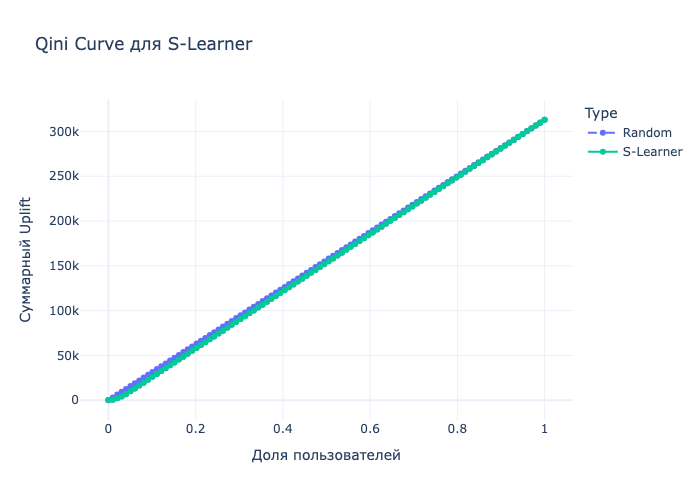

In [43]:
# Задаём заглавие для графика
print('\nПостроение "Qini Curve" для "S-Learner":')
print('-' * 123)



# Построение Qini Curve для S-Learner с использованием функции qini_curve_px
qini_curve_px(
    y_true = y_valid,
    uplift_pred = uplift_predict_s,
    treatment = treatment_valid,
    n_bins = 100,
    title = 'Qini Curve для S-Learner',
    xaxis_title = 'Доля пользователей',
    yaxis_title = 'Суммарный Uplift',
    color = 'Type',
    line_dash = 'Type',
    height = 700,
    width = 1200,
    
    line_dash_map = {
        'S-Learner': 'solid', 
        'Random': 'dash'
    },
    
    name = 'S-Learner'
    
)

#### $4.3$

##### **T-learner.**

Теперь построим `T-Learner (Two-Model Learner)`.

T-Learner использует **две отдельные модели**:

  - Одна модель обучается на группе с воздействием (`treatment=1`), предсказывая вероятность конверсии для пользователей, получивших рекламу.
  
  - Вторая модель обучается на контрольной группе (`treatment=0`), предсказывая вероятность конверсии без воздействия.

In [44]:
# Создаём объект класса `TwoModels` для T-Learner
print('\nОбучение T-Learner...\n')
T_learner = models.TwoModels(
    
    # Создаём объект класса `RandomForestClassifier` для обучения модели
    estimator_trmnt = ensemble.RandomForestClassifier(
        n_estimators = 100,
        random_state = 42
    ),
    
    # Создаём объект класса `RandomForestClassifier` для обучения модели
    estimator_ctrl = ensemble.RandomForestClassifier(
        n_estimators = 100,
        random_state = 42
    )
    
)



# Обучаем модель T-Learner на тренировочной выборке
T_learner.fit(
    X = X_train,
    y = y_train,
    treatment = treatment_train
)


Обучение T-Learner...



,estimator_trmnt,RandomForestC...ndom_state=42)
,estimator_ctrl,RandomForestC...ndom_state=42)
,method,'vanilla'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


Сделаем предсказание на валидационной выборке:

In [45]:
# Предсказание 'uplift' на валидационной выборке
uplift_predict_t = T_learner.predict(X_valid)

Оценим качетво с помощью *qini curve*:

In [46]:
# Оценка качества: Qini AUC
qini_score_t = qini_auc_score(
    y_true = y_valid,
    uplift = uplift_predict_t,
    treatment = treatment_valid
)


# Выводим значение Qini AUC
print(f'\nQini AUC на валидационной выборке: {qini_score_t:.4f}')
print('-' * 45)


Qini AUC на валидационной выборке: 0.0763
---------------------------------------------


Построим график:


Построение "Qini Curve" для "T-Learner":
---------------------------------------------------------------------------------------------------------------------------


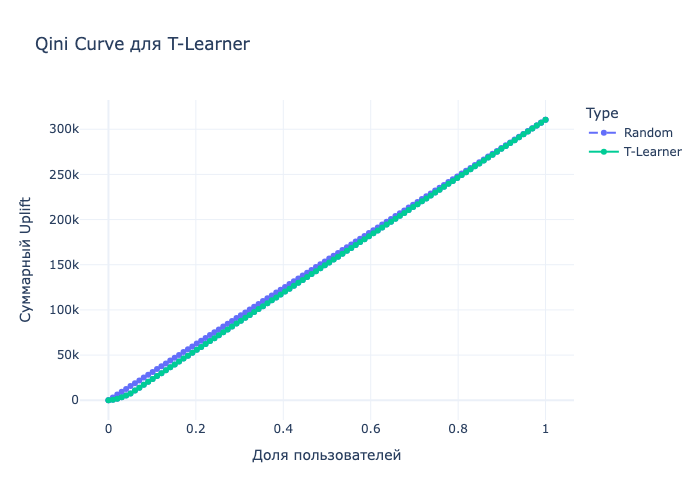

In [47]:
# Задаём заглавие для графика
print('\nПостроение "Qini Curve" для "T-Learner":')
print('-' * 123)



# Построение Qini Curve для T-Learner с использованием функции qini_curve_px
qini_curve_px(
    y_true = y_valid,
    uplift_pred = uplift_predict_t,
    treatment = treatment_valid,
    n_bins = 100,
    title = 'Qini Curve для T-Learner',
    xaxis_title = 'Доля пользователей',
    yaxis_title = 'Суммарный Uplift',
    color = 'Type',
    line_dash = 'Type',
    height = 700,
    width = 1200,
    
    line_dash_map = {
        'T-Learner': 'solid', 
        'Random': 'dash'
    },
    
    name = 'T-Learner'
    
)

#### $4.4$

##### **X-learner.**

Теперь построим `X-Learner`.

$X$-Learner — это мета-алгоритм uplift-моделирования, который:

  - Обучает две модели (для treatment и control групп).
  
  - Вычисляет imputed treatment effects (разницу предсказаний для каждой группы).

  - Обучает две дополнительные модели на imputed effects отдельно для treatment и control групп.

  - Комбинирует предсказания с использованием propensity score или индикатора treatment/control.

In [48]:
# Создаём класс для реализации 'X-Learner'
class XLearner:
    
    
    
    '''
    
    Класс для реализации X-Learner, который использует две модели для оценки uplift.
        
    Параметры:
      - base_estimator_trmnt: модель для treatment группы.
      - base_estimator_ctrl: модель для control группы.
      - propensity_estimator: модель для оценки propensity score.
        
    Использование:
      - Создайте экземпляр класса XLearner, передав модели для treatment и control групп, а также модель для оценки propensity score.
      - Обучите модель на тренировочных данных с помощью метода fit.
      - Используйте метод predict для получения uplift предсказаний на новых данных.
        
    '''
    
    
    
    # Инициализация класса XLearner с базовыми моделями и моделью для оценки propensity score.
    def __init__(self, base_estimator_trmnt, base_estimator_ctrl, propensity_estimator):
        
        '''
        Инициализация класса XLearner.
        Параметры:
          - base_estimator_trmnt: модель для treatment группы.
          - base_estimator_ctrl: модель для control группы.
          - propensity_estimator: модель для оценки propensity score.
        '''
        
        self.model_trmnt = base_estimator_trmnt
        self.model_ctrl = base_estimator_ctrl
        self.propensity_model = propensity_estimator
        self.model_tau_trmnt = ensemble.RandomForestRegressor(n_estimators=50, max_depth=5, min_samples_leaf=200, random_state=42, n_jobs=-1)
        self.model_tau_ctrl = ensemble.RandomForestRegressor(n_estimators=50, max_depth=5, min_samples_leaf=200, random_state=42, n_jobs=-1)



    # Метод fit для обучения моделей на тренировочных данных.
    # Обучает модели для treatment и control групп, вычисляет imputed treatment effects и
    def fit(self, X, y, treatment):
        
        '''
        Метод fit для обучения моделей на тренировочных данных.
        Параметры:
          - X: матрица признаков (матрица наблюдений).
          - y: вектор целевой переменной (вектор правильных ответов).
          - treatment: бинарный вектор, указывающий на то, была ли применена обработка (treatment).
        '''
        
        # Обучение моделей для treatment и control групп
        self.model_trmnt.fit(X[treatment == 1], y[treatment == 1])
        self.model_ctrl.fit(X[treatment == 0], y[treatment == 0])

        # Вычисление imputed treatment effects
        X_trmnt = X[treatment == 1]
        y_trmnt = y[treatment == 1]
        X_ctrl = X[treatment == 0]
        y_ctrl = y[treatment == 0]

        # Предсказания для treatment группы
        pred_trmnt_ctrl = self.model_ctrl.predict_proba(X_trmnt)[:, 1]
        tau_trmnt = y_trmnt - pred_trmnt_ctrl  
        
        # Предсказания для control группы
        pred_ctrl_trmnt = self.model_trmnt.predict_proba(X_ctrl)[:, 1]
        tau_ctrl = pred_ctrl_trmnt - y_ctrl  

        # Обучение моделей на imputed effects
        self.model_tau_trmnt.fit(X_trmnt, tau_trmnt)
        self.model_tau_ctrl.fit(X_ctrl, tau_ctrl)

        # Обучение propensity score
        self.propensity_model.fit(X, treatment)
        
        



    # Метод predict для получения uplift предсказаний на новых данных.
    # Предсказывает propensity score, uplift для treatment и control групп, и комбинирует их для получения итогового uplift.
    def predict(self, X):
        
        '''
        Метод predict для получения uplift предсказаний на новых данных.
        
        Параметры:
          - X: матрица признаков (матрица наблюдений) для предсказания.
          
        Возвращает:
          - uplift: предсказанные значения uplift для treatment группы.
        '''
        
        # Предсказание propensity score
        propensity = self.propensity_model.predict_proba(X)[:, 1]

        # Предсказание uplift для treatment и control
        tau_trmnt_pred = self.model_tau_trmnt.predict(X)
        tau_ctrl_pred = self.model_tau_ctrl.predict(X)

        # Комбинирование с использованием propensity score
        uplift = propensity * tau_trmnt_pred + (1 - propensity) * tau_ctrl_pred
        
        
        # Возвращаем предсказанные значения uplift
        return uplift

Обучаем алгоритм:

In [49]:
#Создаём объект класса `XLearner` для X-Learner
print('\nОбучение X-Learner...\n')
X_learner = XLearner(
    base_estimator_trmnt = ensemble.RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=200, random_state=42, n_jobs=-1),
    base_estimator_ctrl = ensemble.RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=200, random_state=42, n_jobs=-1),
    propensity_estimator = linear_model.LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
)


# Обучаем модель X-Learner на тренировочной выборке
X_learner.fit(
    X = X_train,
    y = y_train,
    treatment = treatment_train
)


Обучение X-Learner...



Сделаем предсказание на валидационной выборке:

In [50]:
# Предсказание 'uplift' на валидационной выборке
uplift_predict_x = X_learner.predict(X_valid)

Оценим качетво с помощью *qini curve*:

In [51]:
# Оценка качества: Qini AUC
qini_score_x = qini_auc_score(
    y_true = y_valid,
    uplift = uplift_predict_x,
    treatment = treatment_valid
)


# Выводим значение Qini AUC
print(f'\nQini AUC на валидационной выборке: {qini_score_x:.4f}')
print('-' * 45)


Qini AUC на валидационной выборке: 0.1751
---------------------------------------------


Построим график:


Построение "Qini Curve" для "X-Learner":
---------------------------------------------------------------------------------------------------------------------------


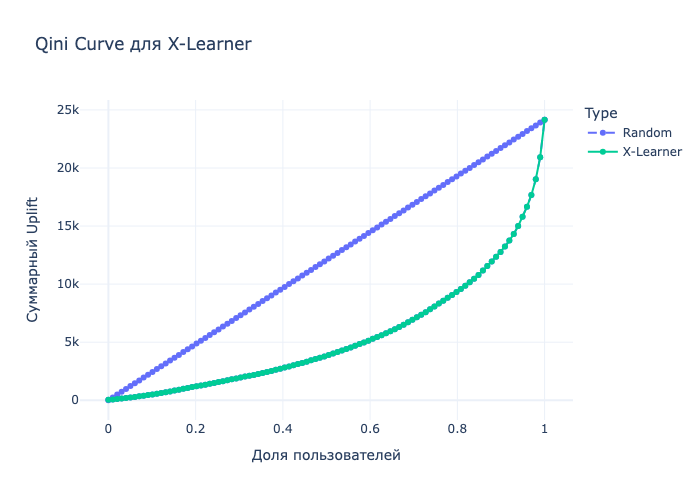

In [52]:
# Задаём заглавие для графика
print('\nПостроение "Qini Curve" для "X-Learner":')
print('-' * 123)



# Построение Qini Curve для X-Learner с использованием функции qini_curve_px
qini_curve_px(
    y_true = y_valid,
    uplift_pred = uplift_predict_x,
    treatment = treatment_valid,
    n_bins = 100,
    title = 'Qini Curve для X-Learner',
    xaxis_title = 'Доля пользователей',
    yaxis_title = 'Суммарный Uplift',
    color = 'Type',
    line_dash = 'Type',
    height = 700,
    width = 1200,
    
    line_dash_map = {
        'X-Learner': 'solid', 
        'Random': 'dash'
    },
    
    name = 'X-Learner'
    
)

#### $4.5$

##### **R-learner.**

Теперь построим `R-Learner`.

$R$-Learner работает следующим образом:

  - Обучаем модель для предсказания исхода (outcome) на всех данных, чтобы получить ожидаемые значения $ \hat{\mu}(X) = E[Y|X] $.
  
  - Обучаем модель для предсказания propensity score $ \hat{e}(X) = P(T=1|X) $.

  - Вычисляем целевую переменную для $R$-Learner:

    $\tilde{Y} = \frac{Y - \hat{\mu}(X)}{T - \hat{e}(X)}$

    где $ Y $ — исход, $ T $ — индикатор лечения, $ \hat{\mu}(X) $ — предсказанный исход, $ \hat{e}(X) $ — propensity score.

  - Обучаем модель регрессии на $ \tilde{Y} $ для предсказания uplift.

  - Предсказываем uplift как $ \hat{\tau}(X) $.

In [53]:
# Создаём класс для реализации 'R-Learner'
class RLearner:
    
    
    
    ''' 
    
    Класс для реализации R-Learner, который использует три модели:
      - модель для исхода (outcome),
      - модель для propensity score,
      - модель для uplift.
    
    Параметры:
      - outcome_estimator: модель для исхода (outcome).
      - propensity_estimator: модель для оценки propensity score.
      - uplift_estimator: модель для оценки uplift.
      
    '''
    
    
    
    # Инициализация класса RLearner с тремя моделями.
    def __init__(self, outcome_estimator, propensity_estimator, uplift_estimator):
        
        '''
        Инициализация класса RLearner.
        
        Параметры:
          - outcome_estimator: модель для исхода (outcome).
          - propensity_estimator: модель для оценки propensity score.
          - uplift_estimator: модель для оценки uplift.
        '''
        
        self.outcome_model = outcome_estimator
        self.propensity_model = propensity_estimator
        self.uplift_model = uplift_estimator
        
        
        
    # Метод fit для обучения моделей на тренировочных данных.
    def fit(self, X, y, treatment):
        
        '''
        Метод fit для обучения моделей на тренировочных данных.
        
        Параметры:
          - X: матрица признаков (матрица наблюдений).
          - y: вектор целевой переменной (вектор правильных ответов).
          - treatment: бинарный вектор, указывающий на то, была ли применена обработка (treatment).
        '''
        
        # Обучение модели для исхода (outcome)
        self.outcome_model.fit(X, y)

        # Обучение модели для propensity score
        self.propensity_model.fit(X, treatment)

        # Вычисление expected outcome и propensity score
        mu_hat = self.outcome_model.predict_proba(X)[:, 1] if hasattr(self.outcome_model, 'predict_proba') else self.outcome_model.predict(X)
        e_hat = self.propensity_model.predict_proba(X)[:, 1]

        # Вычисление целевой переменной для R-Learner
        denominator = treatment - e_hat
        denominator = np.where(np.abs(denominator) < 1e-8, np.sign(denominator) * 1e-8, denominator)
        y_tilde = (y - mu_hat) / denominator

        # Обучение модели на y_tilde для предсказания uplift
        self.uplift_model.fit(X, y_tilde)



    # Метод predict для получения uplift предсказаний на новых данных.
    def predict(self, X):
        
        '''
        Метод predict для получения uplift предсказаний на новых данных.
        Параметры:
          - X: матрица признаков (матрица наблюдений) для предсказания.
          
        Возвращает:
          - uplift: предсказанные значения uplift для treatment группы.
        '''
        
        # Предсказание propensity score
        uplift = self.uplift_model.predict(X)
        
        
        
        # Возвращаем предсказанные значения uplift
        return uplift

Обучаем алгоритм:

In [54]:
# Создаём объект класса `RLearner` для R-Learner
print('\nОбучение R-Learner...')
R_learner = RLearner(
    outcome_estimator = ensemble.RandomForestRegressor(n_estimators=50, max_depth=5, min_samples_leaf=200, random_state=42, n_jobs=-1),
    propensity_estimator = linear_model.LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    uplift_estimator = ensemble.RandomForestRegressor(n_estimators=50, max_depth=5, min_samples_leaf=200, random_state=42, n_jobs=-1)
)



# Обучаем модель R-Learner на тренировочной выборке
R_learner.fit(
    X = X_train,
    y = y_train,
    treatment = treatment_train
)   


Обучение R-Learner...


Сделаем предсказание на валидационной выборке:

In [55]:
# Предсказание 'uplift' на валидационной выборке
uplift_predict_r = R_learner.predict(X_valid)

Оценим качетво с помощью *qini curve*:

In [56]:
# Оценка качества: Qini AUC
qini_score_r = qini_auc_score(
    y_true = y_valid,
    uplift = uplift_predict_r,
    treatment = treatment_valid
)


# Выводим значение Qini AUC
print(f'\nQini AUC на валидационной выборке: {qini_score_r:.4f}')
print('-' * 45)


Qini AUC на валидационной выборке: 0.0908
---------------------------------------------


Построим график:


Построение "Qini Curve" для "R-Learner":
---------------------------------------------------------------------------------------------------------------------------


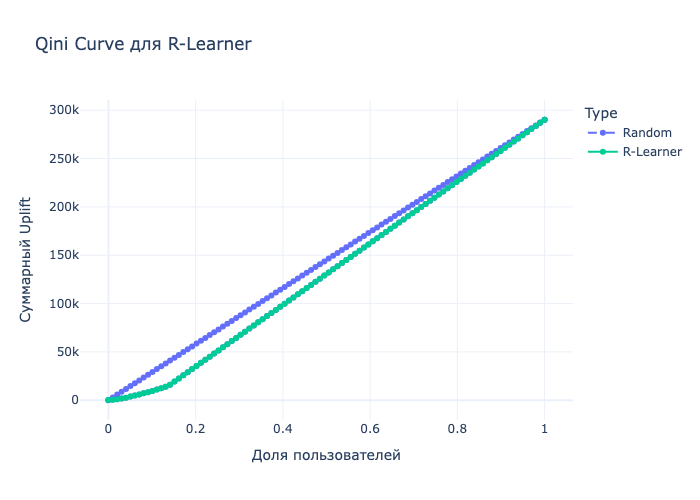

In [57]:
# Задаём заглавие для графика
print('\nПостроение "Qini Curve" для "R-Learner":')
print('-' * 123)



# Построение Qini Curve для R-Learner с использованием функции qini_curve_px
qini_curve_px(
    y_true = y_valid,
    uplift_pred = uplift_predict_r,
    treatment = treatment_valid,
    n_bins = 100,
    title = 'Qini Curve для R-Learner',
    xaxis_title = 'Доля пользователей',
    yaxis_title = 'Суммарный Uplift',
    color = 'Type',
    line_dash = 'Type',
    height = 700,
    width = 1200,
    
    line_dash_map = {
        'R-Learner': 'solid', 
        'Random': 'dash'
    },
    
    name = 'R-Learner'
    
)

#### $4.6$

##### **UpliftRandomForest.**

Теперь построим `UpliftRandomForest`:

In [58]:
# Создаём класс для реализации 'Uplift Random Forest'
class CustomUpliftRandomForest:
    
    
    
    ''' 
    
    Класс для реализации Uplift Random Forest, который использует две модели:
      - модель для trmnt,
      - модель для ctrl.
      
    Параметры:
      - n_estimators: количество деревьев.
      - max_depth: максимальная глубина деревьев.
      - min_samples_leaf: количество листьев.
      
    '''
    
    
    
    # Инициализируем классы 'RandomForestRegressor' для trmnt и ctrl
    def __init__(self, n_estimators=50, max_depth=5, min_samples_leaf=200, random_state=42, n_jobs=-1):
        
        '''
        Инициализация класса XLearner.
        Параметры:
          - base_estimator_trmnt: модель для treatment группы.
          - base_estimator_ctrl: модель для control группы.
        '''
        
        self.model_trmnt = ensemble.RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=random_state, n_jobs=n_jobs
        )
        self.model_ctrl = ensemble.RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=random_state, n_jobs=n_jobs
        )
    
    
    
    # Обучение моделей для treatment и control групп
    def fit(self, X, y, treatment):
      
        '''
        Метод fit для обучения моделей на тренировочных данных.
        Параметры:
          - X: матрица признаков (матрица наблюдений).
          - y: вектор целевой переменной (вектор правильных ответов).
          - treatment: бинарный вектор, указывающий на то, была ли применена обработка (treatment).
        '''
      
        self.model_trmnt.fit(X[treatment == 1], y[treatment == 1])
        self.model_ctrl.fit(X[treatment == 0], y[treatment == 0])
    
    
    
    # Предсказание uplift как разница между treatment и control
    def predict(self, X):
      
        '''
        Метод predict для получения uplift предсказаний на новых данных.
        
        Параметры:
          - X: матрица признаков (матрица наблюдений) для предсказания.
          
        Возвращает:
          - uplift: предсказанные значения uplift для treatment группы.
        '''
        
        pred_trmnt = self.model_trmnt.predict(X)
        pred_ctrl = self.model_ctrl.predict(X)
        uplift = pred_trmnt - pred_ctrl
        
        # Возвращаем результат
        return uplift

Обучаем алгоритм:

In [59]:
# Обучение CustomUpliftRandomForest
print('\nОбучение CustomUpliftRandomForest...')
uplift_rf = CustomUpliftRandomForest(
    n_estimators = 50,
    max_depth = 5,
    min_samples_leaf = 200,
    random_state = 42,
    n_jobs = -1
)


# Обучаем модель CustomUpliftRandomForest на тренировочной выборке
uplift_rf.fit(
    X = X_train,
    y = y_train,
    treatment = treatment_train
)


Обучение CustomUpliftRandomForest...


Сделаем предсказание на валидационной выборке:

In [60]:
# Предсказание 'uplift' на валидационной выборке
uplift_predict_rf = uplift_rf.predict(X_valid)

Оценим качетво с помощью *qini curve*:

In [61]:
# Оценка качества: Qini AUC
qini_score_rf = qini_auc_score(
    y_true = y_valid,
    uplift = uplift_predict_rf,
    treatment = treatment_valid
)


# Выводим значение Qini AUC
print(f'\nQini AUC на валидационной выборке: {qini_score_r:.4f}')
print('-' * 45)


Qini AUC на валидационной выборке: 0.0908
---------------------------------------------


Построим график:


Построение "Qini Curve" для "UpliftRandomForest":
---------------------------------------------------------------------------------------------------------------------------


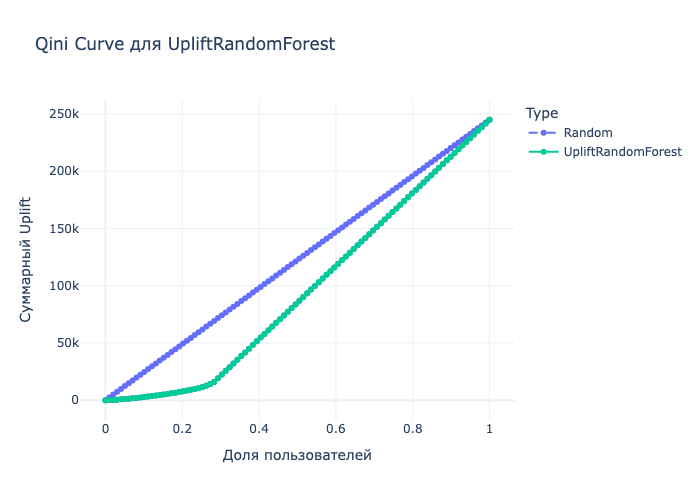

In [62]:
# Задаём заглавие для графика
print('\nПостроение "Qini Curve" для "UpliftRandomForest":')
print('-' * 123)



# Построение Qini Curve для R-Learner с использованием функции qini_curve_px
qini_curve_px(
    y_true = y_valid,
    uplift_pred = uplift_predict_rf,
    treatment = treatment_valid,
    n_bins = 100,
    title = 'Qini Curve для UpliftRandomForest',
    xaxis_title = 'Доля пользователей',
    yaxis_title = 'Суммарный Uplift',
    color = 'Type',
    line_dash = 'Type',
    height = 700,
    width = 1200,
    
    line_dash_map = {
        'UpliftRandomForest': 'solid', 
        'Random': 'dash'
    },
    
    name = 'UpliftRandomForest'
    
)

=============================================================================================================================================

## <center> **`5.` Вывод**

На данном этапе сделаем итоговый вывод о том, какие модели лучше использовать в этом бизнес-кейсе.

На основании полученных результатов по моделям можно заключить следующее:

* `X-Learner` максимизирует **ROI**, так как лучше всего идентифицирует пользователей с высоким uplift (**Qini AUC**: $0.1751$). Это критично, если бюджет кампании ограничен, и вы хотите таргетировать только тех, кто с высокой вероятностью откликнется.

* `R-Learner` или `UpliftRandomForest` также подходят, так как у них одинаковая производительность, значительно лучше *S-Learner* и *T-Learner*, но хуже *X-Learner*.

* `S-Learner` (**Qini AUC**: $0.0360$) и `T-Learner` (**Qini AUC**: $0.0639$) использовать не рекомендуется из-за низкой производительности.